In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# More tools here -- for lower-level implementation of cross-validation

# Three functions for cross-validation
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate
from sklearn.linear_model import Ridge, Lasso, LogisticRegression, LinearRegression
from sklearn.linear_model import RidgeCV, LassoCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score,roc_auc_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error,mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, roc_curve, auc

## 4) Data

#### Cleaning the Train Data

In [10]:
# Train Data Quick Look
train = pd.read_csv('Jan_2019_ontime.csv')
display(train.head())
print(train.shape)
print(train.columns)

,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN,...,DEST,DEP_TIME,DEP_DEL15,DEP_TIME_BLK,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
0,1,2,9E,20363,9E,N8688C,3280,11953,1195302,GNV,...,ATL,601.0,0.0,0600-0659,722.0,0.0,0.0,0.0,300.0,NaN
1,1,2,9E,20363,9E,N348PQ,3281,13487,1348702,MSP,...,CVG,1359.0,0.0,1400-1459,1633.0,0.0,0.0,0.0,596.0,NaN
2,1,2,9E,20363,9E,N8896A,3282,11433,1143302,DTW,...,CVG,1215.0,0.0,1200-1259,1329.0,0.0,0.0,0.0,229.0,NaN
3,1,2,9E,20363,9E,N8886A,3283,15249,1524906,TLH,...,ATL,1521.0,0.0,1500-1559,1625.0,0.0,0.0,0.0,223.0,NaN
4,1,2,9E,20363,9E,N8974C,3284,10397,1039707,ATL,...,FSM,1847.0,0.0,1900-1959,1940.0,0.0,0.0,0.0,579.0,NaN


(583985, 22)
Index(['DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER',
       'OP_CARRIER_AIRLINE_ID', 'OP_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM',
       'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN',
       'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST', 'DEP_TIME',
       'DEP_DEL15', 'DEP_TIME_BLK', 'ARR_TIME', 'ARR_DEL15', 'CANCELLED',
       'DIVERTED', 'DISTANCE', 'Unnamed: 21'],
      dtype='object')


In [11]:
train.isnull().sum()

DAY_OF_MONTH                  0
DAY_OF_WEEK                   0
OP_UNIQUE_CARRIER             0
OP_CARRIER_AIRLINE_ID         0
OP_CARRIER                    0
TAIL_NUM                   2543
OP_CARRIER_FL_NUM             0
ORIGIN_AIRPORT_ID             0
ORIGIN_AIRPORT_SEQ_ID         0
ORIGIN                        0
DEST_AIRPORT_ID               0
DEST_AIRPORT_SEQ_ID           0
DEST                          0
DEP_TIME                  16352
DEP_DEL15                 16355
DEP_TIME_BLK                  0
ARR_TIME                  17061
ARR_DEL15                 18022
CANCELLED                     0
DIVERTED                      0
DISTANCE                      0
Unnamed: 21              583985
dtype: int64

In [12]:
print('Number of Cancelled Flights:',len(train.loc[train['CANCELLED'] == 1]))

print('Number of Diverted Flights:',len(train.loc[train['DIVERTED'] == 1]))

# The number of cancelled flights is very similar to the number of nulls for departure times
# The sum of cancelled and diverted flights is similar to the number of nulls for arrival times

Number of Cancelled Flights: 16726
Number of Diverted Flights: 1296


In [13]:
# Correlation Between Variables:
train.corr(numeric_only = True)

,DAY_OF_MONTH,DAY_OF_WEEK,OP_CARRIER_AIRLINE_ID,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEP_TIME,DEP_DEL15,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
DAY_OF_MONTH,1.000000,-0.031008,-0.000832,-0.011573,-0.004999,-0.004999,-0.004968,-0.004968,-0.001552,0.027989,0.003573,0.038639,0.114638,0.001380,-0.020388,NaN
DAY_OF_WEEK,-0.031008,1.000000,0.007982,0.060343,0.005933,0.005933,0.005667,0.005667,0.003695,-0.003223,0.005445,-0.000655,-0.007829,0.000606,0.018932,NaN
OP_CARRIER_AIRLINE_ID,-0.000832,0.007982,1.000000,0.448922,-0.048516,-0.048516,-0.048707,-0.048708,0.005913,0.041896,-0.019375,0.079238,0.030872,0.012428,-0.128071,NaN
OP_CARRIER_FL_NUM,-0.011573,0.060343,0.448922,1.000000,-0.056559,-0.056559,-0.061254,-0.061254,0.008914,0.026323,0.004557,0.038640,0.047368,0.008912,-0.344293,NaN
ORIGIN_AIRPORT_ID,-0.004999,0.005933,-0.048516,-0.056559,1.000000,1.000000,0.018098,0.018099,-0.036042,0.003860,-0.005888,0.008482,0.012835,-0.000705,0.091660,NaN
ORIGIN_AIRPORT_SEQ_ID,-0.004999,0.005933,-0.048516,-0.056559,1.000000,1.000000,0.018099,0.018099,-0.036042,0.003860,-0.005888,0.008482,0.012836,-0.000705,0.091661,NaN
DEST_AIRPORT_ID,-0.004968,0.005667,-0.048707,-0.061254,0.018098,0.018099,1.000000,1.000000,0.028729,0.012610,0.021741,0.015540,0.012131,0.005459,0.091720,NaN
DEST_AIRPORT_SEQ_ID,-0.004968,0.005667,-0.048708,-0.061254,0.018099,0.018099,1.000000,1.000000,0.028728,0.012610,0.021740,0.015540,0.012132,0.005459,0.091721,NaN
DEP_TIME,-0.001552,0.003695,0.005913,0.008914,-0.036042,-0.036042,0.028729,0.028728,1.000000,0.190625,0.671127,0.143283,0.004093,0.003185,-0.027002,NaN
DEP_DEL15,0.027989,-0.003223,0.041896,0.026323,0.003860,0.003860,0.012610,0.012610,0.190625,1.000000,0.088328,0.719430,0.021686,0.020641,0.011619,NaN


In [14]:
# Conclusions from Quick Look:
    # Drop unnamed column
    # 'TAIL NUM' has nulls. 'TAIL_NUM' is an aircraft identifier. It is not necessary for this project, so it can be dropped
    # 'DEP_TIME','DEP_DEL15','ARR_DEL15','ARR_TIME' have nulls but are all valuable components for predictive analysis
        # There are usually nulls when flights were cancelled or diverted; therefore, it is not necessary to impute (see code above)
        # Because 'ARR_DEL15' will be used as the target variable, the nulls will need to be dropped since its not possible to impute for cancelled/diverted flights

In [15]:
train = train.drop(columns = 'Unnamed: 21')
train = train.drop(columns = 'TAIL_NUM')

In [16]:
train = train[(train["CANCELLED"] == 0.0) & (train["DIVERTED"] == 0.0)] #only keeps flights that were not diverted or cancelled

# IMPORTANT CAVEAT! We are only doing this because we want to model delays. if we need these vars as predcitors/response var, they can't be dropped

In [17]:
# Final check
train.isnull().sum()

DAY_OF_MONTH             0
DAY_OF_WEEK              0
OP_UNIQUE_CARRIER        0
OP_CARRIER_AIRLINE_ID    0
OP_CARRIER               0
OP_CARRIER_FL_NUM        0
ORIGIN_AIRPORT_ID        0
ORIGIN_AIRPORT_SEQ_ID    0
ORIGIN                   0
DEST_AIRPORT_ID          0
DEST_AIRPORT_SEQ_ID      0
DEST                     0
DEP_TIME                 0
DEP_DEL15                0
DEP_TIME_BLK             0
ARR_TIME                 0
ARR_DEL15                0
CANCELLED                0
DIVERTED                 0
DISTANCE                 0
dtype: int64

#### Cleaning the Test Data

In [18]:
# Train Data Quick Look
test = pd.read_csv('Jan_2020_ontime.csv')
display(test.head())
print(test.shape)
print(test.columns)
# appears to have same cols as train data

,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN,...,DEST,DEP_TIME,DEP_DEL15,DEP_TIME_BLK,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
0,1,3,EV,20366,EV,N48901,4397,13930,1393007,ORD,...,GRB,1003.0,0.0,1000-1059,1117.0,0.0,0.0,0.0,174.0,NaN
1,1,3,EV,20366,EV,N16976,4401,15370,1537002,TUL,...,ORD,1027.0,0.0,1000-1059,1216.0,0.0,0.0,0.0,585.0,NaN
2,1,3,EV,20366,EV,N12167,4404,11618,1161802,EWR,...,TYS,1848.0,0.0,1800-1859,2120.0,0.0,0.0,0.0,631.0,NaN
3,1,3,EV,20366,EV,N14902,4405,10781,1078105,BTR,...,IAH,1846.0,0.0,1800-1859,2004.0,0.0,0.0,0.0,253.0,NaN
4,1,3,EV,20366,EV,N606UX,4407,14524,1452401,RIC,...,IAH,1038.0,0.0,1000-1059,1330.0,0.0,0.0,0.0,1157.0,NaN


(607346, 22)
Index(['DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER',
       'OP_CARRIER_AIRLINE_ID', 'OP_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM',
       'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN',
       'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST', 'DEP_TIME',
       'DEP_DEL15', 'DEP_TIME_BLK', 'ARR_TIME', 'ARR_DEL15', 'CANCELLED',
       'DIVERTED', 'DISTANCE', 'Unnamed: 21'],
      dtype='object')


In [19]:
# Correlation Between Vars:
test.corr(numeric_only = True)

,DAY_OF_MONTH,DAY_OF_WEEK,OP_CARRIER_AIRLINE_ID,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEP_TIME,DEP_DEL15,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
DAY_OF_MONTH,1.000000,-0.053947,-0.001769,-0.020052,-0.004940,-0.004940,-0.004954,-0.004954,-0.005020,-0.054577,0.008519,-0.050177,-0.010167,-0.000348,-0.020724,NaN
DAY_OF_WEEK,-0.053947,1.000000,0.007127,0.056448,0.005209,0.005209,0.004852,0.004852,0.006285,0.052912,-0.002774,0.056028,0.039705,0.002754,0.019665,NaN
OP_CARRIER_AIRLINE_ID,-0.001769,0.007127,1.000000,0.425973,-0.046500,-0.046500,-0.046669,-0.046670,0.000718,0.031618,-0.011144,0.063539,0.001645,0.011046,-0.126079,NaN
OP_CARRIER_FL_NUM,-0.020052,0.056448,0.425973,1.000000,-0.052829,-0.052830,-0.058687,-0.058688,0.004227,0.024615,0.010911,0.031619,0.021812,0.006071,-0.351157,NaN
ORIGIN_AIRPORT_ID,-0.004940,0.005209,-0.046500,-0.052829,1.000000,1.000000,0.016854,0.016854,-0.029354,0.001784,-0.002609,0.007438,0.011100,-0.001496,0.087739,NaN
ORIGIN_AIRPORT_SEQ_ID,-0.004940,0.005209,-0.046500,-0.052830,1.000000,1.000000,0.016854,0.016854,-0.029353,0.001784,-0.002609,0.007438,0.011100,-0.001496,0.087740,NaN
DEST_AIRPORT_ID,-0.004954,0.004852,-0.046669,-0.058687,0.016854,0.016854,1.000000,1.000000,0.034886,0.006621,0.026064,0.005681,0.010061,0.000805,0.087738,NaN
DEST_AIRPORT_SEQ_ID,-0.004954,0.004852,-0.046670,-0.058688,0.016854,0.016854,1.000000,1.000000,0.034886,0.006621,0.026064,0.005681,0.010061,0.000805,0.087738,NaN
DEP_TIME,-0.005020,0.006285,0.000718,0.004227,-0.029354,-0.029353,0.034886,0.034886,1.000000,0.154965,0.666769,0.115073,0.002015,-0.006154,-0.015937,NaN
DEP_DEL15,-0.054577,0.052912,0.031618,0.024615,0.001784,0.001784,0.006621,0.006621,0.154965,1.000000,0.073039,0.711257,0.015603,0.020670,0.013399,NaN


In [20]:
# correlation with the response var:
dep_time_dummies = pd.get_dummies(test['DEP_TIME_BLK'], prefix='DEP_TIME_BLK')
numeric_cols = test.select_dtypes(include='number')
df_corr = pd.concat([dep_time_dummies, numeric_cols], axis=1)
correlations = df_corr.corr(numeric_only=True)
dep_time_corr = correlations.loc[dep_time_dummies.columns, numeric_cols.columns]
pd.DataFrame(dep_time_corr)

,DAY_OF_MONTH,DAY_OF_WEEK,OP_CARRIER_AIRLINE_ID,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEP_TIME,DEP_DEL15,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
DEP_TIME_BLK_0001-0559,-0.006068,-0.003866,0.024081,-0.003875,0.004660,0.004660,-0.051436,-0.051436,-0.283165,-0.030136,-0.236088,-0.022221,-0.001923,0.000262,-0.014380,NaN
DEP_TIME_BLK_0600-0659,-0.002040,-0.004384,-0.007359,0.000232,0.026506,0.026506,-0.028326,-0.028326,-0.405168,-0.062187,-0.335457,-0.042015,-0.004595,0.003084,-0.006467,NaN
DEP_TIME_BLK_0700-0759,0.002491,-0.003130,-0.015895,-0.034051,-0.001449,-0.001449,0.003146,0.003146,-0.330608,-0.048670,-0.260674,-0.026301,-0.004359,0.006317,0.038163,NaN
DEP_TIME_BLK_0800-0859,0.001496,0.002928,-0.016667,-0.006069,0.003954,0.003954,0.026018,0.026018,-0.268087,-0.033400,-0.206814,-0.015798,-0.004442,0.004638,0.029240,NaN
DEP_TIME_BLK_0900-0959,0.002587,-0.000499,0.006003,0.002968,-0.006832,-0.006832,0.005023,0.005023,-0.203239,-0.020653,-0.148335,-0.014450,-0.007011,-0.000876,0.010194,NaN
DEP_TIME_BLK_1000-1059,-0.000280,0.001525,-0.000312,0.009069,-0.002784,-0.002783,-0.003283,-0.003283,-0.149656,-0.002931,-0.102147,-0.006029,-0.002749,0.000100,-0.008554,NaN
DEP_TIME_BLK_1100-1159,0.001316,0.000470,0.004781,0.007351,0.021174,0.021174,-0.007050,-0.007050,-0.102520,-0.003906,-0.055998,-0.007120,-0.006939,-0.000957,0.003331,NaN
DEP_TIME_BLK_1200-1259,0.002518,0.000432,0.011809,0.017147,0.005074,0.005074,-0.016800,-0.016800,-0.049874,0.004129,-0.005931,-0.000876,-0.001831,0.000446,-0.011465,NaN
DEP_TIME_BLK_1300-1359,0.001105,-0.000777,-0.007104,-0.000234,-0.002003,-0.002003,0.004047,0.004047,0.002920,0.008945,0.043915,0.000305,-0.001895,-0.001382,-0.004773,NaN
DEP_TIME_BLK_1400-1459,-0.000237,0.003105,0.014034,0.023518,-0.003095,-0.003095,-0.004510,-0.004509,0.054208,0.017509,0.086184,0.009952,0.003271,-0.002376,-0.020719,NaN


In [21]:
# Perform the same cleaning steps as the train data
test = test.drop(columns = 'Unnamed: 21')
test = test.drop(columns = 'TAIL_NUM')
test = test[(test["CANCELLED"] == 0.0) & (test["DIVERTED"] == 0.0)] #only keeps flights that were not diverted or cancelled
test.isnull().sum()

DAY_OF_MONTH             0
DAY_OF_WEEK              0
OP_UNIQUE_CARRIER        0
OP_CARRIER_AIRLINE_ID    0
OP_CARRIER               0
OP_CARRIER_FL_NUM        0
ORIGIN_AIRPORT_ID        0
ORIGIN_AIRPORT_SEQ_ID    0
ORIGIN                   0
DEST_AIRPORT_ID          0
DEST_AIRPORT_SEQ_ID      0
DEST                     0
DEP_TIME                 0
DEP_DEL15                0
DEP_TIME_BLK             0
ARR_TIME                 0
ARR_DEL15                0
CANCELLED                0
DIVERTED                 0
DISTANCE                 0
dtype: int64

## 5) Prediction

In [22]:
# Checking for imbalance in classes
len(train[train['ARR_DEL15']==1])/len(train[train['ARR_DEL15']==0])

0.22837559496550122

In [23]:
# Checking for imbalance in classes
len(train[train['ARR_DEL15']==1])/len(train)

0.18591674720785634

In [24]:
# Checking for imbalance in classes
len(test[test['ARR_DEL15']==1])/len(test[test['ARR_DEL15']==0])

0.15916384097736289

In [25]:
# Checking for imbalance in classes
len(test[test['ARR_DEL15']==1])/len(test)

0.13730918387098928

In [26]:
# Reminders: need to use scikit-learn, this is a classification project, ridge can work fine for this project
# Response Variable: ARR_DEL15
# Predictors: 
    # `DISTANCE` and transformed `DEP_TIME`
    # `DAY_OF_MONTH` and `DAY_OF_WEEK` to see how delays fluctuate throughout the month
    # `OP_UNIQUE_CARRIER` / `OP_CARRIER` / `OP_CARRIER_AIRLINE_ID`/`ORIGIN` / `DEST` / `DEP_TIME_BLK`

# Note: we are trying to predict if our flight will arrive late BEFORE departure. 
    # So while `DEP_DEL15` had the strongest correlation, we don't know if a flight at departure will be delayed before departure

In [27]:
# Order of priority for predictors: DEP_TIME_BLK, DISTANCE, DAY_OF_WEEK, ORIGIN, OP_UNIQUE_CARRIER

In [28]:
# Building the model with DEP_TIME_BLK

# One-hot predictor -- do not need to scale with OHE
X_train = pd.get_dummies(train['DEP_TIME_BLK'], drop_first=True)
X_test = pd.get_dummies(test['DEP_TIME_BLK'], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train['ARR_DEL15']
y_test = test['ARR_DEL15']

# Logistic model
logreg = LogisticRegression(penalty = None)
logreg.fit(X_train, y_train)

LogisticRegression(penalty=None)

In [29]:
# Predictions
y_pred_test = logreg.predict(X_test)
y_pred_train = logreg.predict(X_train)
y_prob_test = logreg.predict_proba(X_test)[:,1]
y_prob_train = logreg.predict_proba(X_train)[:,1]

# Metrics
test_acc_1 = accuracy_score(y_test, y_pred_test)*100
train_acc_1 = accuracy_score(y_train, y_pred_train)*100
test_rec_1 = recall_score(y_test, y_pred_test)*100
train_rec_1 = recall_score(y_train, y_pred_train)*100
test_prec_1 = precision_score(y_test, y_pred_test,zero_division=0)*100
train_prec_1 = precision_score(y_train, y_pred_train,zero_division=0)*100
test_auc_1 = roc_auc_score(y_test, y_prob_test)
train_auc_1 = roc_auc_score(y_train, y_prob_train)

print("Test Accuracy:", test_acc_1)
print("Test Recall:", test_rec_1)
print("Test Precision:", test_prec_1)
print("Test AUC:", test_auc_1)

print("Train Accuracy:", train_acc_1)
print("Train Recall:", train_rec_1)
print("Train Precision:", train_prec_1)
print("Train AUC:", train_auc_1)

Test Accuracy: 86.26908161290108
Test Recall: 0.0
Test Precision: 0.0
Test AUC: 0.5627155760677055
Train Accuracy: 81.40832527921437
Train Recall: 0.0
Train Precision: 0.0
Train AUC: 0.5746654286055035


In [30]:
# Notice that recall is 0...didn't predict any as delayed
# let's try changing the threshold
y_pred_prob_test = logreg.predict_proba(X_test)[:,1]
y_pred_test = (y_pred_prob_test > 0.2).astype(int)
y_pred_prob_train = logreg.predict_proba(X_train)[:,1]
y_pred_train = (y_pred_prob_train > 0.2).astype(int)

test_acc = accuracy_score(y_test, y_pred_test)*100
train_acc = accuracy_score(y_train, y_pred_train)*100
test_rec = recall_score(y_test, y_pred_test)*100
train_rec = recall_score(y_train, y_pred_train)*100

print('Test Accuracy:', test_acc)
print('Test Recall:', test_rec)
print('Train Accuracy:', train_acc)
print('Train Recall:', train_rec)

Test Accuracy: 56.93662935447913
Test Recall: 51.36416114723218
Train Accuracy: 57.3053362145582
Train Recall: 52.32746003687442


In [31]:
# Conclusion --> need to go below 0.5 do get a recall that's not 0 (at least when we use DEP_TIME_BLK as the only predictor)
# Let's add another predictor: DISTANCE

X_train_time = pd.get_dummies(train['DEP_TIME_BLK'], drop_first=True)
X_test_time = pd.get_dummies(test['DEP_TIME_BLK'], drop_first=True)
X_test_time = X_test_time.reindex(columns=X_train_time.columns, fill_value=0)

# add DISTANCE
X_train = pd.concat([X_train_time, train[['DISTANCE']]], axis=1)
X_test = pd.concat([X_test_time, test[['DISTANCE']]], axis=1)

y_train = train['ARR_DEL15']
y_test = test['ARR_DEL15']

# Scale
scaler = StandardScaler()
scaler.fit(X_train) 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
logreg = LogisticRegression(penalty = None,max_iter = 1000)
logreg.fit(X_train_scaled, y_train)

# Predict
# Predictions
y_pred_test = logreg.predict(X_test_scaled)
y_pred_train = logreg.predict(X_train_scaled)
y_prob_test = logreg.predict_proba(X_test_scaled)[:,1]
y_prob_train = logreg.predict_proba(X_train_scaled)[:,1]

# Metrics
test_acc_2 = accuracy_score(y_test, y_pred_test)*100
train_acc_2 = accuracy_score(y_train, y_pred_train)*100
test_rec_2 = recall_score(y_test, y_pred_test)*100
train_rec_2 = recall_score(y_train, y_pred_train)*100
test_prec_2 = precision_score(y_test, y_pred_test,zero_division=0)*100
train_prec_2 = precision_score(y_train, y_pred_train,zero_division=0)*100
test_auc_2 = roc_auc_score(y_test, y_prob_test)
train_auc_2 = roc_auc_score(y_train, y_prob_train)

print("Test Accuracy:", test_acc_2)
print("Test Recall:", test_rec_2)
print("Test Precision:", test_prec_2)
print("Test AUC:", test_auc_2)
print("Train Accuracy:", train_acc_2)
print("Train Recall:", train_rec_2)
print("Train Precision:", train_prec_2)
print("Train AUC:", train_auc_2)

Test Accuracy: 86.26908161290108
Test Recall: 0.0
Test Precision: 0.0
Test AUC: 0.563695608972498
Train Accuracy: 81.40832527921437
Train Recall: 0.0
Train Precision: 0.0
Train AUC: 0.5753578229439796


In [32]:
# ADD DAY_OF_THE_WEEK -- need to OHE
day_train = pd.get_dummies(train['DAY_OF_WEEK'], drop_first=True)
day_test = pd.get_dummies(test['DAY_OF_WEEK'], drop_first=True)
day_test = day_test.reindex(columns=day_train.columns, fill_value=0)

X_train = pd.concat([X_train_time, day_train, train[['DISTANCE']]], axis=1)
X_test = pd.concat([X_test_time, day_test, test[['DISTANCE']]], axis=1)

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

y_train = train['ARR_DEL15']
y_test = test['ARR_DEL15']

# Scale
scaler = StandardScaler()
scaler.fit(X_train) 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
logreg = LogisticRegression(penalty = None,max_iter = 1000)
logreg.fit(X_train_scaled, y_train)

# Predict
y_pred_test = logreg.predict(X_test_scaled)
y_pred_train = logreg.predict(X_train_scaled)
y_prob_test = logreg.predict_proba(X_test_scaled)[:,1]
y_prob_train = logreg.predict_proba(X_train_scaled)[:,1]

# Performance
test_acc_3 = accuracy_score(y_test, y_pred_test)*100
train_acc_3 = accuracy_score(y_train, y_pred_train)*100
test_rec_3 = recall_score(y_test, y_pred_test)*100
train_rec_3 = recall_score(y_train, y_pred_train)*100
test_prec_3 = precision_score(y_test, y_pred_test,zero_division=0)*100
train_prec_3 = precision_score(y_train, y_pred_train,zero_division=0)*100
test_auc_3 = roc_auc_score(y_test, y_prob_test)
train_auc_3 = roc_auc_score(y_train, y_prob_train)
print("Test Accuracy:", test_acc_3)
print("Test Recall:", test_rec_3)
print("Test Precision:", test_prec_3)
print("Test AUC:", test_auc_3)
print("Train Accuracy:", train_acc_3)
print("Train Recall:", train_rec_3)
print("Train Precision:", train_prec_3)
print("Train AUC:", train_auc_3)

Test Accuracy: 86.26908161290108
Test Recall: 0.0
Test Precision: 0.0
Test AUC: 0.5494112834755657
Train Accuracy: 81.40832527921437
Train Recall: 0.0
Train Precision: 0.0
Train AUC: 0.5810804649986844


In [33]:
# Add ORIGIN as a predictor -- also need to OHE
time_train = pd.get_dummies(train['DEP_TIME_BLK'], drop_first=True)
time_test = pd.get_dummies(test['DEP_TIME_BLK'], drop_first=True)
time_test = time_test.reindex(columns=time_train.columns, fill_value=0)
day_train = pd.get_dummies(train['DAY_OF_WEEK'].astype(str), drop_first=True)
day_test = pd.get_dummies(test['DAY_OF_WEEK'].astype(str), drop_first=True)
day_test = day_test.reindex(columns=day_train.columns, fill_value=0)
origin_train = pd.get_dummies(train['ORIGIN'], drop_first=True)
origin_test = pd.get_dummies(test['ORIGIN'], drop_first=True)
origin_test = origin_test.reindex(columns=origin_train.columns, fill_value=0)

X_train = pd.concat([time_train, day_train, origin_train, train[['DISTANCE']]], axis=1)
X_test = pd.concat([time_test, day_test, origin_test, test[['DISTANCE']]], axis=1)

# make column names consistent for sklearn
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# TARGET
y_train = train['ARR_DEL15']
y_test = test['ARR_DEL15']

# SCALE
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# PREDICT
y_pred_test = logreg.predict(X_test_scaled)
y_pred_train = logreg.predict(X_train_scaled)
y_prob_test = logreg.predict_proba(X_test_scaled)[:,1]
y_prob_train = logreg.predict_proba(X_train_scaled)[:,1]

# PERFORMANCE
test_acc_4 = accuracy_score(y_test, y_pred_test)*100
train_acc_4 = accuracy_score(y_train, y_pred_train)*100
test_rec_4 = recall_score(y_test, y_pred_test)*100
train_rec_4 = recall_score(y_train, y_pred_train)*100
test_prec_4 = precision_score(y_test, y_pred_test,zero_division=0)*100
train_prec_4 = precision_score(y_train, y_pred_train,zero_division=0)*100
test_auc_4 = roc_auc_score(y_test, y_prob_test)
train_auc_4 = roc_auc_score(y_train, y_prob_train)
print("Test Accuracy:", test_acc_4)
print("Test Recall:", test_rec_4)
print("Test Precision:", test_prec_4)
print("Test AUC:", test_auc_4)
print("Train Accuracy:", train_acc_4)
print("Train Recall:", train_rec_4)
print("Train Precision:", train_prec_4)
print("Train AUC:", train_auc_4)

Test Accuracy: 86.25923626824726
Test Recall: 0.04496566810475785
Test Precision: 27.819548872180448
Test AUC: 0.5609005872988275
Train Accuracy: 81.40744182923618
Train Recall: 0.04371709338351295
Train Precision: 47.42268041237113
Train AUC: 0.6306205866789656


In [34]:
# Add ORIGIN and OP_UNIQUE_CARRIER as predictors -- also need to OHE
time_train = pd.get_dummies(train['DEP_TIME_BLK'], drop_first=True)
time_test = pd.get_dummies(test['DEP_TIME_BLK'], drop_first=True)
time_test = time_test.reindex(columns=time_train.columns, fill_value=0)
day_train = pd.get_dummies(train['DAY_OF_WEEK'].astype(str), drop_first=True)
day_test = pd.get_dummies(test['DAY_OF_WEEK'].astype(str), drop_first=True)
day_test = day_test.reindex(columns=day_train.columns, fill_value=0)
origin_train = pd.get_dummies(train['ORIGIN'], drop_first=True)
origin_test = pd.get_dummies(test['ORIGIN'], drop_first=True)
origin_test = origin_test.reindex(columns=origin_train.columns, fill_value=0)
carrier_train = pd.get_dummies(train['OP_UNIQUE_CARRIER'], drop_first=True)
carrier_test = pd.get_dummies(test['OP_UNIQUE_CARRIER'], drop_first=True)
carrier_test = carrier_test.reindex(columns=carrier_train.columns, fill_value=0)
X_train = pd.concat([time_train, day_train, origin_train, carrier_train, train[['DISTANCE']]], axis=1)
X_test = pd.concat([time_test, day_test, origin_test, carrier_test, test[['DISTANCE']]], axis=1)
# make column names consistent for sklearn
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)
# TARGET
y_train = train['ARR_DEL15']
y_test = test['ARR_DEL15']
# SCALE
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
# MODEL
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
# PREDICT
y_pred_test = logreg.predict(X_test_scaled)
y_pred_train = logreg.predict(X_train_scaled)
y_prob_test = logreg.predict_proba(X_test_scaled)[:,1]
y_prob_train = logreg.predict_proba(X_train_scaled)[:,1]
# PERFORMANCE
test_acc_5 = accuracy_score(y_test, y_pred_test)*100
train_acc_5 = accuracy_score(y_train, y_pred_train)*100
test_rec_5 = recall_score(y_test, y_pred_test)*100
train_rec_5 = recall_score(y_train, y_pred_train)*100
test_prec_5 = precision_score(y_test, y_pred_test,zero_division=0)*100
train_prec_5 = precision_score(y_train, y_pred_train,zero_division=0)*100
test_auc_5 = roc_auc_score(y_test, y_prob_test)
train_auc_5 = roc_auc_score(y_train, y_prob_train)
print("Test Accuracy:", test_acc_5)
print("Test Recall:", test_rec_5)
print("Test Precision:", test_prec_5)
print("Test AUC:", test_auc_5)
print("Train Accuracy:", train_acc_5)
print("Train Recall:", train_rec_5)
print("Train Precision:", train_prec_5)
print("Train AUC:", train_auc_5)

Test Accuracy: 86.24555290788095
Test Recall: 0.08507018290089324
Test Precision: 24.91103202846975
Test AUC: 0.5687505658527084
Train Accuracy: 81.40567492927983
Train Recall: 0.10073938910113854
Train Precision: 46.69603524229075
Train AUC: 0.6427327575109887


In [35]:
# Putting the results into a df:
results_df = pd.DataFrame({
    'Model': [1, 2, 3, 4, 5],
    'Predictors': [
        'DEP_TIME_BLK',
        'DEP_TIME_BLK, DAY_OF_WEEK',
        'DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE',
        'DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE, ORIGIN',
        'DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE, ORIGIN, OP_UNIQUE_CARRIER'
    ],
    'Test Accuracy':   [test_acc_1,  test_acc_2,  test_acc_3,  test_acc_4,  test_acc_5],
    'Train Accuracy':  [train_acc_1, train_acc_2, train_acc_3, train_acc_4, train_acc_5],
    'Test Recall':     [test_rec_1,  test_rec_2,  test_rec_3,  test_rec_4,  test_rec_5],
    'Train Recall':    [train_rec_1, train_rec_2, train_rec_3, train_rec_4, train_rec_5],
    'Test Precision':  [test_prec_1, test_prec_2, test_prec_3, test_prec_4, test_prec_5],
    'Train Precision': [train_prec_1,train_prec_2,train_prec_3,train_prec_4,train_prec_5],
    'Test AUC':        [test_auc_1,  test_auc_2,  test_auc_3,  test_auc_4,  test_auc_5],
    'Train AUC':       [train_auc_1, train_auc_2, train_auc_3, train_auc_4, train_auc_5]
})

results_df

,Model,Predictors,Test Accuracy,Train Accuracy,Test Recall,Train Recall,Test Precision,Train Precision,Test AUC,Train AUC
0,1,DEP_TIME_BLK,86.269082,81.408325,0.000000,0.000000,0.000000,0.000000,0.562716,0.574665
1,2,"DEP_TIME_BLK, DAY_OF_WEEK",86.269082,81.408325,0.000000,0.000000,0.000000,0.000000,0.563696,0.575358
2,3,"DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE",86.269082,81.408325,0.000000,0.000000,0.000000,0.000000,0.549411,0.581080
3,4,"DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE, ORIGIN",86.259236,81.407442,0.044966,0.043717,27.819549,47.422680,0.560901,0.630621
4,5,"DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE, ORIGIN, O...",86.245553,81.405675,0.085070,0.100739,24.911032,46.696035,0.568751,0.642733


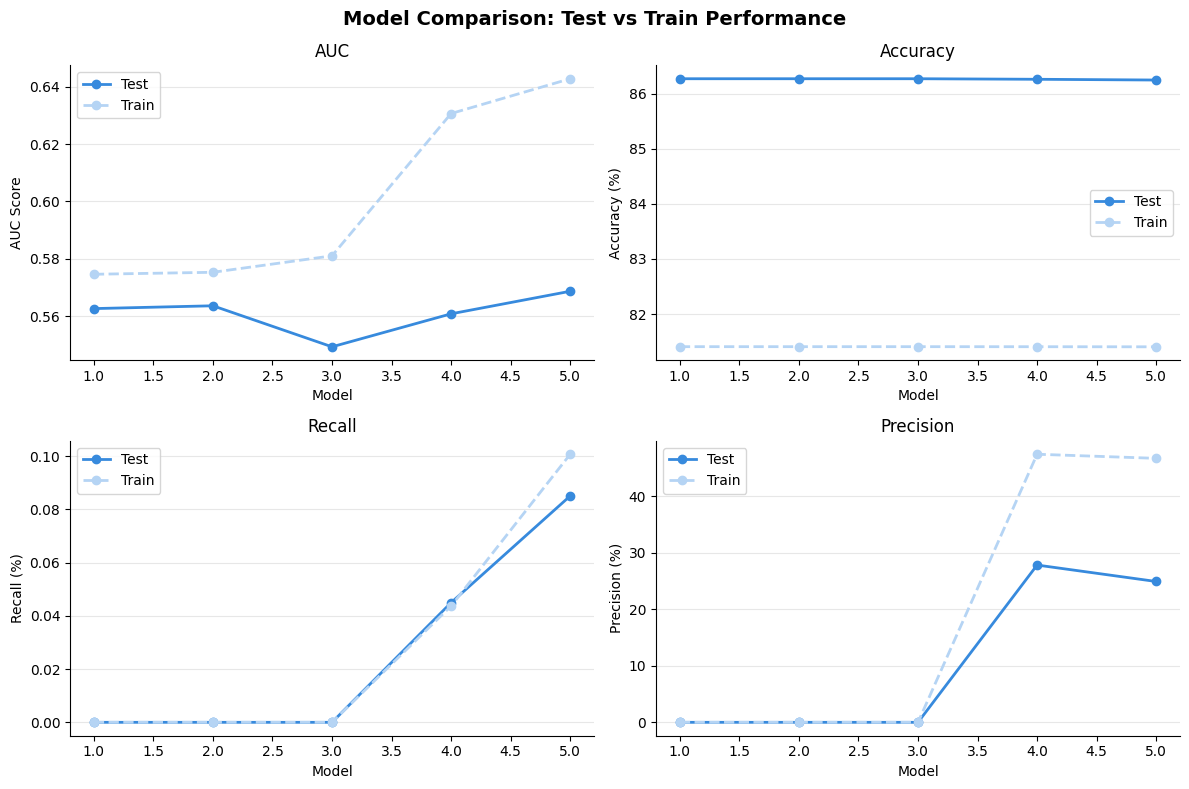

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# AUC
axes[0,0].plot(results_df['Model'], results_df['Test AUC'],  marker='o', label='Test',  color='#378ADD', linewidth=2)
axes[0,0].plot(results_df['Model'], results_df['Train AUC'], marker='o', label='Train', color='#B5D4F4', linewidth=2, linestyle='--')
axes[0,0].set_title('AUC')
axes[0,0].set_xlabel('Model')
axes[0,0].set_ylabel('AUC Score')
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)
axes[0,0].spines[['top', 'right']].set_visible(False)

# Accuracy
axes[0,1].plot(results_df['Model'], results_df['Test Accuracy'],  marker='o', label='Test',  color='#378ADD', linewidth=2)
axes[0,1].plot(results_df['Model'], results_df['Train Accuracy'], marker='o', label='Train', color='#B5D4F4', linewidth=2, linestyle='--')
axes[0,1].set_title('Accuracy')
axes[0,1].set_xlabel('Model')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)
axes[0,1].spines[['top', 'right']].set_visible(False)

# Recall
axes[1,0].plot(results_df['Model'], results_df['Test Recall'],  marker='o', label='Test',  color='#378ADD', linewidth=2)
axes[1,0].plot(results_df['Model'], results_df['Train Recall'], marker='o', label='Train', color='#B5D4F4', linewidth=2, linestyle='--')
axes[1,0].set_title('Recall')
axes[1,0].set_xlabel('Model')
axes[1,0].set_ylabel('Recall (%)')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)
axes[1,0].spines[['top', 'right']].set_visible(False)

# Precision
axes[1,1].plot(results_df['Model'], results_df['Test Precision'],  marker='o', label='Test',  color='#378ADD', linewidth=2)
axes[1,1].plot(results_df['Model'], results_df['Train Precision'], marker='o', label='Train', color='#B5D4F4', linewidth=2, linestyle='--')
axes[1,1].set_title('Precision')
axes[1,1].set_xlabel('Model')
axes[1,1].set_ylabel('Precision (%)')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)
axes[1,1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Model Comparison: Test vs Train Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Regularization and Cross-Validation

#### Numeric Var is Brought to Order 2 ONLY

In [37]:
import warnings
warnings.filterwarnings('ignore')

# Regularization/Cross-Validation
numeric_cols = ['DISTANCE']  # you can add more numeric columns if available
categorical_cols = [col for col in X_train.columns if col not in numeric_cols]

X_train_num = X_train[numeric_cols]
X_test_num  = X_test[numeric_cols]

X_train_cat = X_train[categorical_cols]
X_test_cat  = X_test[categorical_cols]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_num)
X_test_poly  = poly.transform(X_test_num)

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled  = scaler.transform(X_test_poly)

X_train = np.hstack([X_train_poly_scaled, X_train_cat.values])
X_test  = np.hstack([X_test_poly_scaled, X_test_cat.values])

# reducing size because the dataset is massive
np.random.seed(42)

# random sample indices
idx = np.random.choice(X_train.shape[0], 5000, replace=False)

# subset X and y
X_train_small = X_train[idx]
y_train_small = y_train.iloc[idx] 

Cs = np.logspace(-2, 2, 4) 
cv = 5
max_iter = 1000               

logreg = LogisticRegressionCV(
    penalty='l1',
    solver='saga',
    Cs=Cs,
    cv=cv,
    scoring='roc_auc',
    max_iter=max_iter,
    n_jobs=-1,
)

logreg.fit(X_train_small, y_train_small)

LogisticRegressionCV(Cs=array([1.00000000e-02, 2.15443469e-01, 4.64158883e+00, 1.00000000e+02]),
                     cv=5, max_iter=1000, n_jobs=-1, penalty='l1',
                     scoring='roc_auc', solver='saga')

In [38]:
# Predictions:
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:,1]

print('Test Performance of the Trained and Tuned Model:')
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test AUC:", roc_auc_score(y_test, y_prob))
print("Test Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Test Recall:", recall_score(y_test, y_pred, zero_division=0))

Test Performance of the Trained and Tuned Model:
Test Accuracy: 0.8625673321452172
Test AUC: 0.5537056617485039
Test Precision: 0.12244897959183673
Test Recall: 0.0001458345992586741


In [39]:
#| echo: false
# Extracting polynomial feature names:
poly_names = poly.get_feature_names_out(numeric_cols)

all_feature_names = list(poly_names) + list(categorical_cols)

#getting the top 3 most important non-linear terms
coef = logreg.coef_[0]

coef_df = pd.DataFrame({
    "term": all_feature_names,
    "coefficient": coef,
    "abs_coef": np.abs(coef)
})

top3 = coef_df.sort_values("abs_coef", ascending=False).head(3)

top3['is_polynomial'] = top3['term'].apply(lambda x: x in poly_names)

print('Three Most Important Terms')
top3[["term", "coefficient", "is_polynomial"]]

Three Most Important Terms


,term,coefficient,is_polynomial
263,ORD,0.723358,False
214,LGA,0.549989,False
2,0600-0659,-0.506327,False


In [40]:
#| echo: false
# Least informative predictors:
print('Three Least Important Terms')
bottom3 = coef_df.sort_values("abs_coef", ascending=True).head(3)
bottom3[["term","coefficient"]]

Three Least Important Terms


,term,coefficient
193,JAN,0.0
255,OAK,0.0
254,OAJ,0.0


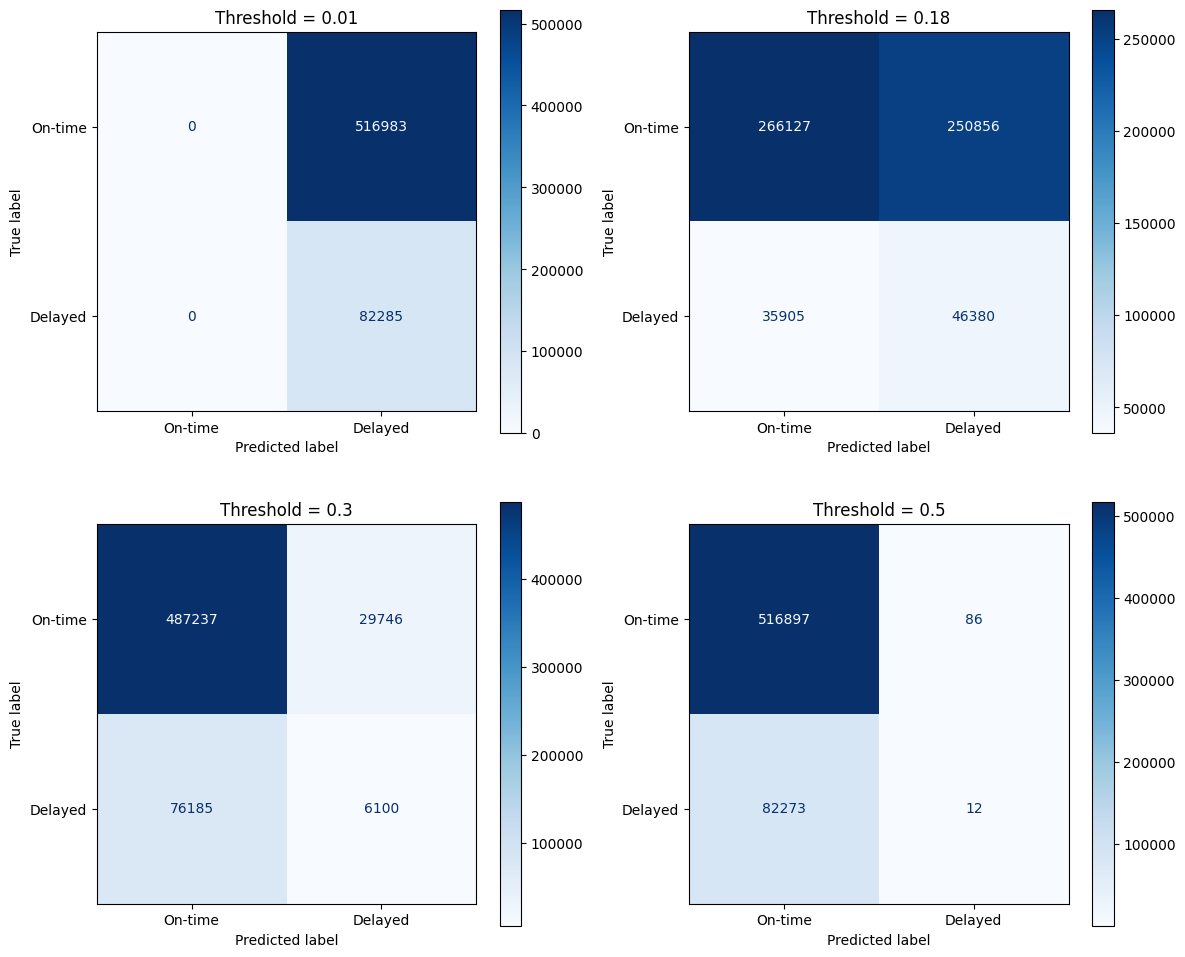

In [41]:
#| echo: false
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Thresholds to visualize
thresholds = [0.01, 0.18, 0.3, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(12,10))

for ax, threshold in zip(axes.flatten(), thresholds):
    # Apply threshold
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred_threshold)
    
    # Display confusion matrix on the subplot
    disp = ConfusionMatrixDisplay(cm, display_labels=["On-time", "Delayed"])
    disp.plot(cmap="Blues", values_format='d', ax=ax)
    ax.set_title(f"Threshold = {threshold}")

plt.tight_layout()
plt.show();

#### All Vars are Brought to Order 2 and Looking at Interaction/Transformation Terms Now

In [42]:
import warnings
warnings.filterwarnings("ignore")

# make it smaller 
np.random.seed(42)
idx = np.random.choice(train.shape[0], 5000, replace=False)
train_small = train.iloc[idx].copy()
y_train_small = y_train.iloc[idx].copy()

# reduce cat vars

# ORIGIN: top 3 + 'Other'
top_airports = train_small['ORIGIN'].value_counts().nlargest(3).index
train_small['ORIGIN_MOD'] = train_small['ORIGIN'].where(train_small['ORIGIN'].isin(top_airports), 'Other')

# OP_UNIQUE_CARRIER: top 3 + 'Other'
top_carriers = train_small['OP_UNIQUE_CARRIER'].value_counts().nlargest(3).index
train_small['CARRIER_MOD'] = train_small['OP_UNIQUE_CARRIER'].where(train_small['OP_UNIQUE_CARRIER'].isin(top_carriers), 'Other')

# DEP_TIME_BLK: top 3 + '0600-0659' + 'Other'
top_time_blocks = train_small['DEP_TIME_BLK'].value_counts().nlargest(3).index.tolist()
if '0600-0659' not in top_time_blocks:
    top_time_blocks.append('0600-0659')
train_small['DEP_TIME_BLK_MOD'] = train_small['DEP_TIME_BLK'].where(
    train_small['DEP_TIME_BLK'].isin(top_time_blocks), 'Other'
)

# OHE (redo it for organization)
X_time = pd.get_dummies(train_small['DEP_TIME_BLK_MOD'], drop_first=True)
X_origin = pd.get_dummies(train_small['ORIGIN_MOD'], drop_first=True)
X_carrier = pd.get_dummies(train_small['CARRIER_MOD'], drop_first=True)

# Numeric column
X_numeric = train_small[['DISTANCE']]

# Combine all features
X_train_full = pd.concat([X_numeric.reset_index(drop=True),
                          X_time.reset_index(drop=True),
                          X_origin.reset_index(drop=True),
                          X_carrier.reset_index(drop=True)], axis=1)

# poly
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_full)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)

# logreg
Cs = np.logspace(-2, 2, 10)  # regularization strengths
logreg = LogisticRegressionCV(
    penalty='l1',
    solver='saga',
    Cs=Cs,
    cv=5,
    scoring='roc_auc',
    max_iter=1000,
    n_jobs=-1
)

# Fit the model
logreg.fit(X_train_scaled, y_train_small)

LogisticRegressionCV(Cs=array([1.00000000e-02, 2.78255940e-02, 7.74263683e-02, 2.15443469e-01,
       5.99484250e-01, 1.66810054e+00, 4.64158883e+00, 1.29154967e+01,
       3.59381366e+01, 1.00000000e+02]),
                     cv=5, max_iter=1000, n_jobs=-1, penalty='l1',
                     scoring='roc_auc', solver='saga')

In [43]:
# Create a dictionary for top categories
top_summary = {
    'Variable': ['ORIGIN', 'OP_UNIQUE_CARRIER', 'DEP_TIME_BLK'],
    'Top Categories': [
        list(top_airports),
        list(top_carriers),
        top_time_blocks  # already includes '0600-0659' if added
    ]
}

# Convert to DataFrame
top_df = pd.DataFrame(top_summary)

# Optionally show nicely
top_df

,Variable,Top Categories
0,ORIGIN,"[ATL, DFW, ORD]"
1,OP_UNIQUE_CARRIER,"[WN, AA, DL]"
2,DEP_TIME_BLK,"[0600-0659, 0800-0859, 1800-1859]"


In [44]:
numeric_cols = ['DISTANCE']
categorical_cols = ['ORIGIN_MOD', 'CARRIER_MOD', 'DEP_TIME_BLK_MOD']

test = test.copy()

# Apply same top-category + 'Other' mapping as train_small
test['ORIGIN_MOD'] = test['ORIGIN'].where(test['ORIGIN'].isin(top_airports), 'Other')
test['CARRIER_MOD'] = test['OP_UNIQUE_CARRIER'].where(test['OP_UNIQUE_CARRIER'].isin(top_carriers), 'Other')
test['DEP_TIME_BLK_MOD'] = test['DEP_TIME_BLK'].where(test['DEP_TIME_BLK'].isin(top_time_blocks), 'Other')

X_time_test = pd.get_dummies(test['DEP_TIME_BLK_MOD'], drop_first=True)
X_time_test = X_time_test.reindex(columns=X_time.columns, fill_value=0)

X_origin_test = pd.get_dummies(test['ORIGIN_MOD'], drop_first=True)
X_origin_test = X_origin_test.reindex(columns=X_origin.columns, fill_value=0)

X_carrier_test = pd.get_dummies(test['CARRIER_MOD'], drop_first=True)
X_carrier_test = X_carrier_test.reindex(columns=X_carrier.columns, fill_value=0)

# Combine numeric + categorical
X_test_full = pd.concat([test[numeric_cols].reset_index(drop=True),
                         X_time_test.reset_index(drop=True),
                         X_origin_test.reset_index(drop=True),
                         X_carrier_test.reset_index(drop=True)], axis=1)


X_test_poly = poly.transform(X_test_full)  # poly was fit on X_train_full

X_test_scaled = scaler.transform(X_test_poly)


y_pred = logreg.predict(X_test_scaled)
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]


print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test AUC:", roc_auc_score(y_test, y_prob))
print("Test Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Test Recall:", recall_score(y_test, y_pred, zero_division=0))

Test Accuracy: 0.8624838970210323
Test AUC: 0.5644407969984653
Test Precision: 0.15168539325842698
Test Recall: 0.0003281278483320168


In [45]:
poly_names = poly.get_feature_names_out(X_train_full.columns)  # all features, numeric + dummies

coef = logreg.coef_[0]

coef_df = pd.DataFrame({
    "term": poly_names,
    "coefficient": coef,
    "abs_coef": np.abs(coef)
})

top3 = coef_df.sort_values("abs_coef", ascending=False).head(3)

top3[["term", "coefficient"]]

,term,coefficient
39,Other ORD,0.152724
12,DISTANCE 1800-1859,0.118727
40,Other Other,0.098481


In [46]:
# Is there non-linearity in top 3? 
top3['is_polynomial'] = top3['term'].apply(lambda x: x in poly_names)

top3[["term", "coefficient", "is_polynomial"]]

,term,coefficient,is_polynomial
39,Other ORD,0.152724,True
12,DISTANCE 1800-1859,0.118727,True
40,Other Other,0.098481,True


In [47]:
# Least informative predictors:
bottom3 = coef_df.sort_values("abs_coef", ascending=True).head(3)
bottom3[["term","coefficient"]]

,term,coefficient
0,DISTANCE,0.0
23,0800-0859 DFW,0.0
25,0800-0859 Other,0.0


In [48]:
# Let's also tune the decision threshold
thresholds = np.linspace(0.01, 0.5, 50)

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    recall = recall_score(y_test, y_pred_t, zero_division=0)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    
    results.append([t, recall, precision])

threshold_df = pd.DataFrame(results, columns=["threshold", "recall", "precision"])

In [49]:
best_row = threshold_df.loc[threshold_df["recall"].idxmax()]
print(best_row)

threshold    0.010000
recall       1.000000
precision    0.137309
Name: 0, dtype: float64


In [50]:
# By lowering the classification threshold to 0.01, the model successfully identifies all delayed flights (recall = 1.0)
# However, the vast majority of predicted delays are false positives (precision ≈ 0.14)
# This illustrates the extreme tradeoff between recall and precision in highly imbalanced datasets
    # a very low threshold maximizes detection of rare events but sacrifices predictive reliability.

# KEY FINDING: it’s generally better to prioritize recall over precision, because catching all real delays is more important than avoiding some false alarms.

In [51]:
# Try to balance precision and recall:
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Example: find threshold where recall >= 0.5 but precision is still reasonable
best_threshold = None
for p, r, t in zip(precisions, recalls, thresholds):
    if r >= 0.5 and p >= 0.1:  # tune the minimum precision you accept
        best_threshold = t
        break

print("Best threshold:", best_threshold)

Best threshold: 0.07785205353352277


In [52]:
y_pred_best = (y_pred_proba >= best_threshold).astype(int)

# Evaluate metrics at this threshold
from sklearn.metrics import accuracy_score, precision_score, recall_score
print("Best Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))

Best Threshold: 0.07785205353352277
Accuracy: 0.13730918387098928
Precision: 0.13730918387098928
Recall: 1.0


In [53]:
# We still get extreme results...let's try this as a middle ground:
thr = 0.18
y_pred_best = (y_pred_proba >= thr).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))

Accuracy: 0.5101156744561699
Precision: 0.16136105011780166
Recall: 0.6117639910068664


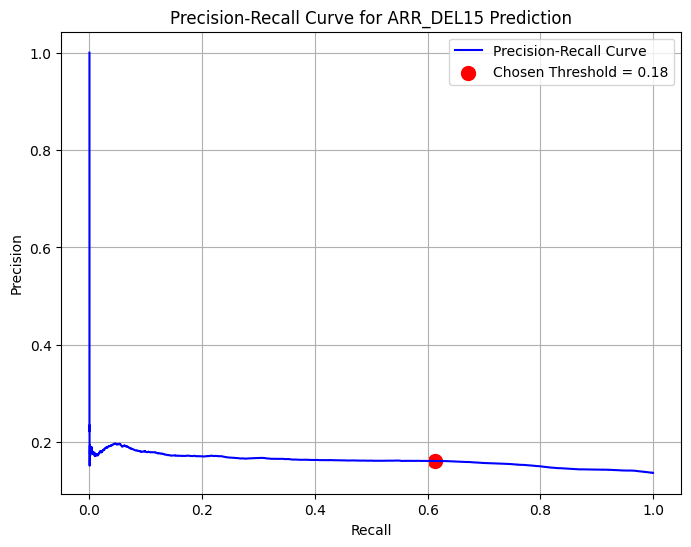

In [54]:
# Let's visualize this phenomenon
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(8,6))
plt.plot(recalls, precisions, label="Precision-Recall Curve", color="blue")

# Mark chosen threshold (e.g., 0.18)
chosen_thr = 0.18
# Find closest threshold in array for annotation
thr_idx = (abs(thresholds - chosen_thr)).argmin()
plt.scatter(recalls[thr_idx], precisions[thr_idx], color="red", s=100, label=f"Chosen Threshold = {chosen_thr}")

# Labels and title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for ARR_DEL15 Prediction")
plt.legend()
plt.grid(True)
plt.show();

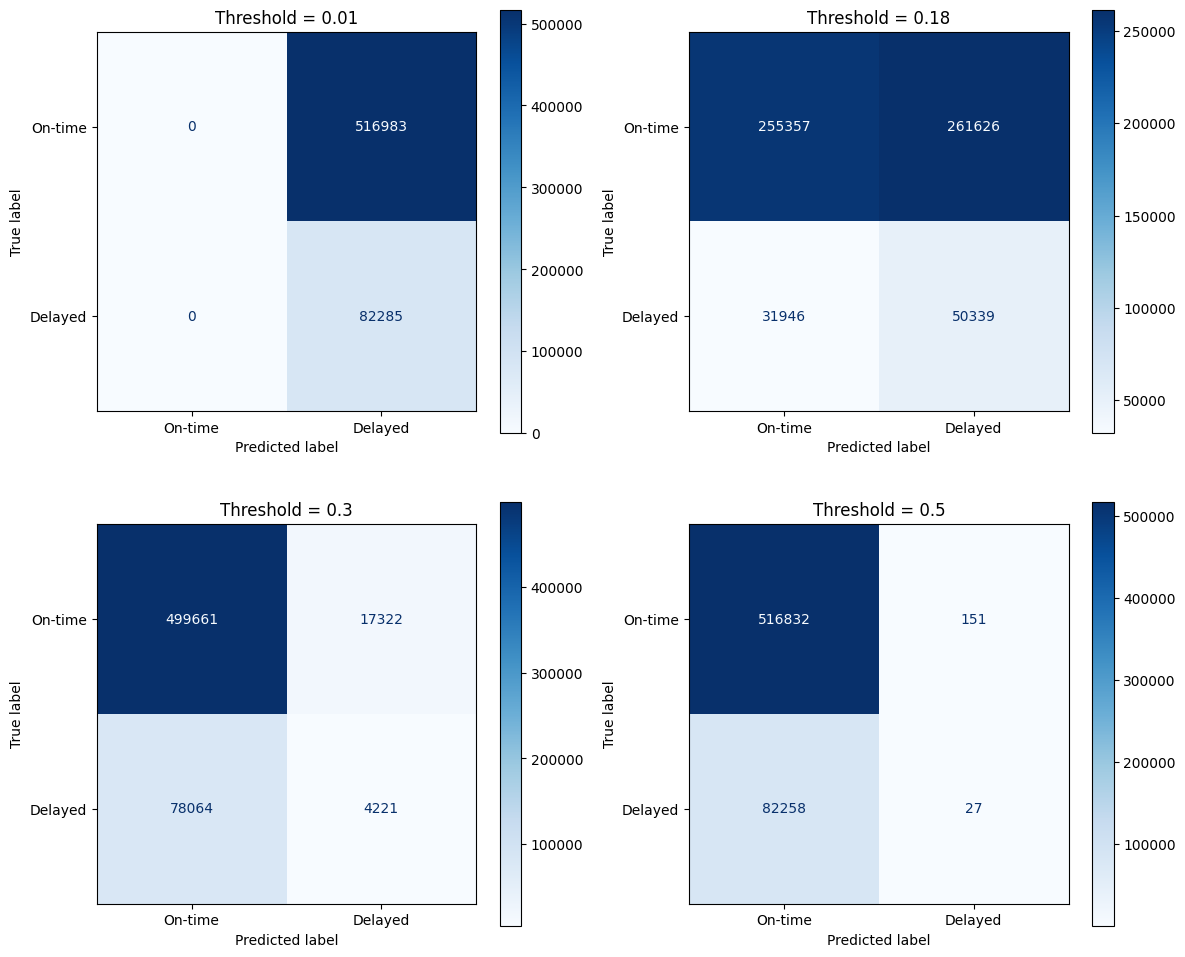

In [55]:
# Let's visualize the confusion matrices
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Thresholds to visualize
thresholds = [0.01, 0.18, 0.3, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(12,10))

for ax, threshold in zip(axes.flatten(), thresholds):
    # Apply threshold
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred_threshold)
    
    # Display confusion matrix on the subplot
    disp = ConfusionMatrixDisplay(cm, display_labels=["On-time", "Delayed"])
    disp.plot(cmap="Blues", values_format='d', ax=ax)
    ax.set_title(f"Threshold = {threshold}")

plt.tight_layout()
plt.show();

## 6) Inference

In [56]:
# Create smaller train size
train_small = train.sample(5000, random_state=42)

# Ensure there are not many categorical vars:
top_airports = train_small['ORIGIN'].value_counts().nlargest(3).index
train_small['ORIGIN_MOD'] = train_small['ORIGIN'].where(train_small['ORIGIN'].isin(top_airports), 'Other')

top_carriers = train_small['OP_UNIQUE_CARRIER'].value_counts().nlargest(3).index
train_small['CARRIER_MOD'] = train_small['OP_UNIQUE_CARRIER'].where(train_small['OP_UNIQUE_CARRIER'].isin(top_carriers), 'Other')

top_time_blocks = train_small['DEP_TIME_BLK'].value_counts().nlargest(3).index.tolist()
train_small['DEP_TIME_BLK_MOD'] = train_small['DEP_TIME_BLK'].where(
    train_small['DEP_TIME_BLK'].isin(top_time_blocks), 'Other'
)

model = smf.logit(
    formula = 'ARR_DEL15 ~ DISTANCE + I(DISTANCE**2) \
               + C(DEP_TIME_BLK_MOD) \
               + C(DAY_OF_WEEK) \
               + C(ORIGIN_MOD) \
               + C(CARRIER_MOD)',
    data = train_small
).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.467376
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              ARR_DEL15   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4982
Method:                           MLE   Df Model:                           17
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                 0.02705
Time:                        18:20:38   Log-Likelihood:                -2336.9
converged:                       True   LL-Null:                       -2401.9
Covariance Type:            nonrobust   LLR p-value:                 1.923e-19
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -2.8717      0.317     -9.053      0.000      -3.493      -2.250
C(DEP_TIME_BLK_MOD)[T.0800-0859]     0.2725      0.234      1.165      0.244      -0.186       0.731
C(DEP_TIME_BLK_MOD)[T.1800-1859]     0.7854      0.218      3.608      0.000       0.359       1.212
C(DEP_TIME_BLK_MOD)[T.Other]         0.7100      0.175      4.054      0.000       0.367       1.053
C(DAY_OF_WEEK)[T.2]                 -0.0138      0.143     -0.097      0.923      -0.293       0.266
C(DAY_OF_WEEK)[T.3]                  0.4175      0.135      3.104      0.002       0.154       0.681
C(DAY_OF_WEEK)[T.4]                  0.1679      0.138      1.220      0.223      -0.102       0.438
C(DAY_OF_WEEK)[T.5]                  0.1991      0.143      1.394      0.163      -0.081       0.479
C(DAY_OF_WEEK)[T.6]                 -0.1682      0.161     -1.042      0.297      -0.484       0.148
C(DAY_OF_WEEK)[T.7]                  0.2772      0.145      1.911      0.056      -0.007       0.561
C(ORIGIN_MOD)[T.DFW]                 0.2824      0.285      0.990      0.322      -0.277       0.841
C(ORIGIN_MOD)[T.ORD]                 1.2125      0.263      4.605      0.000       0.696       1.729
C(ORIGIN_MOD)[T.Other]               0.4405      0.214      2.054      0.040       0.020       0.861
C(CARRIER_MOD)[T.DL]                -0.3668      0.163     -2.243      0.025      -0.687      -0.046
C(CARRIER_MOD)[T.Other]              0.1490      0.114      1.312      0.190      -0.074       0.372
C(CARRIER_MOD)[T.WN]                -0.3129      0.142     -2.205      0.027      -0.591      -0.035
DISTANCE                             0.0002      0.000      1.320      0.187      -0.000       0.001
I(DISTANCE ** 2)                  -3.84e-08   6.91e-08     -0.556      0.578   -1.74e-07     9.7e-08
====================================================================================================
"""

In [57]:
# Baseline for DEP_TIME_BLK IS: '0600-0659'
# Baseline for DAY_OF_WEEK: 1
# Baseline for ORIGIN IS: 'ATL'
# Baseline for CARRIER IS: 'AA'